# MCAR sanity check: scan success vs. domain reach
Check whether failed-scan domains are concentrated in the long tail (low reach) or among popular high-reach sites.

In [1]:
import sys; sys.path.insert(0, '/home/lsys/private_blacklight/scripts')
import pandas as pd
import janitor  # noqa
import matplotlib.pyplot as plt
from constants import filepaths
from utilities import load_visit_data

Checking that all paths exist:
{'web_mobile': True, 'web_desktop': True, 'web': True, 'yg_profile': True, 'blacklight': True, 'who': True}


In [2]:
scanned = (
    pd.read_csv(filepaths['blacklight'], usecols=['filename'])
    .assign(private_domain=lambda d: d['filename'].str.replace('_', '.', regex=False),
            scanned=True)
    .remove_columns('filename')
)

domain_summary = (
    load_visit_data()
    .dropna(subset=['private_domain'])
    .groupby('private_domain')
    .agg(reach=('caseid', 'nunique'), n_visits=('caseid', 'size'))
    .reset_index()
    .merge(scanned, on='private_domain', how='left')
    .assign(scanned=lambda d: d['scanned'].fillna(False))
)
domain_summary.head()

/home/lsys/private_blacklight/bl_venv/lib/python3.10/site-packages/pandas_flavor/register.py:164: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.drop` instead.
  return method(self._obj, *args, **kwargs)


len(df_visits)=6,297,382


/tmp/ipykernel_27656/1083947276.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .assign(scanned=lambda d: d['scanned'].fillna(False))


,private_domain,reach,n_visits,scanned
0,007james.com,1,4,True
1,0123movie.net,6,41,True
2,0410690.com,1,3,False
3,042jam.com,1,15,False
4,042nobs.com,1,2,True


In [3]:
n_total = len(domain_summary)
n_scan = domain_summary['scanned'].sum()
vs_total = domain_summary['n_visits'].sum()
vs_scan = domain_summary.query('scanned')['n_visits'].sum()

print(f'Unique domains in panel: {n_total:,}')
print(f'Scanned successfully:    {n_scan:,} ({n_scan/n_total:.1%})')
print(f'Total visits:            {vs_total:,}')
print(f'Visits to scanned:       {vs_scan:,} ({vs_scan/vs_total:.1%})')
print()
print('Reach distribution by scan status:')
print(
    domain_summary.groupby('scanned')['reach']
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .round(2)
)

Unique domains in panel: 64,074
Scanned successfully:    34,078 (53.2%)
Total visits:            6,236,834
Visits to scanned:       4,767,099 (76.4%)

Reach distribution by scan status:
           count  mean    std  min  50%  75%  90%  95%   99%     max
scanned                                                             
False    29996.0  2.75   8.55  1.0  1.0  2.0  4.0  8.0  33.0   544.0
True     34078.0  3.05  16.04  1.0  1.0  2.0  4.0  8.0  35.0  1080.0


In [4]:
# What fraction of low-reach (singleton, =1) domains are scanned vs higher-reach domains?
for cutoff in [1, 2, 5, 10, 50, 100]:
    sub = domain_summary[domain_summary['reach'] >= cutoff]
    print(f'Reach >= {cutoff:>3}: {len(sub):>6,} domains, scanned share = {sub["scanned"].mean():.1%}')

Reach >=   1: 64,074 domains, scanned share = 53.2%
Reach >=   2: 17,828 domains, scanned share = 52.8%
Reach >=   5:  5,800 domains, scanned share = 51.6%
Reach >=  10:  2,745 domains, scanned share = 51.3%
Reach >=  50:    387 domains, scanned share = 56.3%
Reach >= 100:    130 domains, scanned share = 72.3%


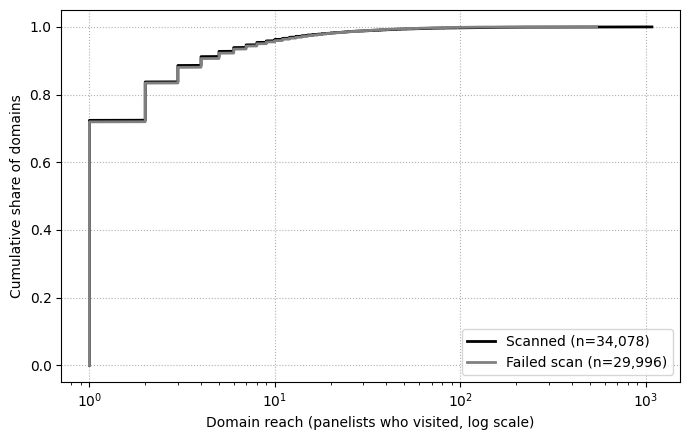

In [ ]:
_, ax = plt.subplots(figsize=(7, 4.5))
for status, color, label in [(True, 'black', 'Scanned'), (False, 'gray', 'Failed scan')]:
    sub = domain_summary.query('scanned == @status')['reach'].sort_values()
    y = (sub.rank(method='first') / len(sub)).values
    ax.plot(sub.values, y, color=color, linewidth=2, label=f'{label} (n={len(sub):,})')
ax.set_xscale('log')
ax.set_xlabel('Domain reach (panelists who visited, log scale)')
ax.set_ylabel('Cumulative share of domains')
ax.legend(loc='lower right')
ax.grid(axis='both', linestyle=':')
plt.tight_layout()